# Loan Approval Decision Engine — Lending Club Dataset
**Domain:** Credit Risk / Retail Banking | **Stack:** Python, Scikit-learn, Matplotlib, Pandas

Same decision engine architecture as the synthetic version, now powered by real Lending Club data (~2.2M loans, 2007–2018).

### Pipeline
1. **Data loading & cleaning** — Lending Club raw CSV → analysis-ready DataFrame
2. **EDA** — real-world distributions, default rates by grade/purpose/term
3. **Feature engineering** — derived ratios, flags, encodings
4. **Logistic Regression PD model** — trained on actual loan outcomes
5. **Threshold tuning** — optimise for bad rate cap / profit / F1
6. **Rule-based override layer** — hard declines + auto-approvals with reason codes
7. **Audit trail & portfolio simulation**

---
> **Dataset:** Download `accepted_2007_to_2018Q4.csv` from  
> https://www.kaggle.com/datasets/wordsforthewise/lending-club  
> Place it in a `data/` folder next to this notebook.


## 0. Setup

In [ ]:
%pip install --upgrade --force-reinstall numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model     import LogisticRegression
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (
    roc_auc_score, roc_curve, f1_score,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
print("Libraries loaded ✓")



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.2
    Uninstalling numpy-2.2.2:
      Successfully uninstalled numpy-2.2.2
Note: you may need to restart the kernel to use updated packages.
Libraries loaded ✓


## 1. Load Lending Club Data

In [3]:
DATA_PATH = 'data/accepted_2007_to_2018Q4.csv'

# Lending Club has 150+ columns — load only what we need
USECOLS = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'verification_status', 'loan_status', 'purpose',
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
]

print(f"Loading {DATA_PATH} ...")
df_raw = pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    low_memory=False,
    nrows=200_000      # ← remove or increase for full dataset; 200k runs fast
)

print(f"Loaded  : {len(df_raw):,} rows  ×  {len(df_raw.columns)} columns")
print(f"Memory  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head(3)


Loading data/accepted_2007_to_2018Q4.csv ...
Loaded  : 200,000 rows  ×  24 columns
Memory  : 116.4 MB


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,delinq_2yrs,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,...,0.0,675.0,679.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,...,1.0,715.0,719.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,...,0.0,695.0,699.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0


## 2. Target Variable — Default Flag

In [4]:
# Lending Club loan_status values we treat as default
DEFAULT_STATUSES = {
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)',   # seriously delinquent — include as early default signal
}

# Keep only loans with a resolved outcome (drop 'Current', 'In Grace Period', etc.)
RESOLVED_STATUSES = DEFAULT_STATUSES | {
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid',
}

df_raw = df_raw[df_raw['loan_status'].isin(RESOLVED_STATUSES)].copy()
df_raw['default'] = df_raw['loan_status'].isin(DEFAULT_STATUSES).astype(int)

print(f"Resolved loans  : {len(df_raw):,}")
print(f"Default rate    : {df_raw['default'].mean():.2%}")
print("\nLoan status breakdown:")
print(df_raw['loan_status'].value_counts().to_string())


Resolved loans  : 176,868
Default rate    : 20.28%

Loan status breakdown:
loan_status
Fully Paid            140992
Charged Off            35090
Late (31-120 days)       785
Default                    1


## 3. Data Cleaning

In [5]:
def clean_lending_club(df):
    df = df.copy()

    # ── Parse term: ' 36 months' → 36 ────────────────────────────────────
    df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)

    # ── Parse int_rate: '13.56%' → 13.56 ─────────────────────────────────
    if df['int_rate'].dtype == object:
        df['int_rate'] = df['int_rate'].str.replace('%','').astype(float)

    # ── Parse revol_util: '45.6%' → 45.6 ─────────────────────────────────
    if df['revol_util'].dtype == object:
        df['revol_util'] = df['revol_util'].str.replace('%','').astype(float)

    # ── Employment length → numeric years ─────────────────────────────────
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8,  '9 years': 9, '10+ years': 10
    }
    df['emp_years'] = df['emp_length'].map(emp_map)

    # ── FICO mid-point ─────────────────────────────────────────────────────
    df['fico_score'] = (df['fico_range_low'].fillna(0) +
                        df['fico_range_high'].fillna(0)) / 2
    df.loc[df['fico_score'] == 0, 'fico_score'] = np.nan

    # ── Grade to numeric ───────────────────────────────────────────────────
    grade_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}
    df['grade_n'] = df['grade'].map(grade_map)

    # ── Derived ratios ─────────────────────────────────────────────────────
    df['payment_to_income'] = (df['installment'] * 12) / df['annual_inc'].clip(lower=1)
    df['loan_to_income']    = df['loan_amnt']           / df['annual_inc'].clip(lower=1)

    # ── Delinquency flag (past 2 years) ───────────────────────────────────
    df['delinq_flag'] = (df['delinq_2yrs'].fillna(0) > 0).astype(int)

    # ── Home ownership simplify ───────────────────────────────────────────
    df['home_ownership'] = df['home_ownership'].replace(
        {'NONE': 'OTHER', 'ANY': 'OTHER'}
    )

    # ── Median imputation for numeric nulls ───────────────────────────────
    num_cols = ['dti','revol_util','open_acc','pub_rec','mort_acc',
                'pub_rec_bankruptcies','emp_years','fico_score',
                'payment_to_income','loan_to_income','annual_inc']
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    return df

df = clean_lending_club(df_raw)
print(f"Cleaned dataset : {df.shape}")
print(f"\nNull counts after cleaning:")
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].to_string())


Cleaned dataset : (176868, 32)

Null counts after cleaning:
emp_length    6.31601


## 4. Exploratory Data Analysis

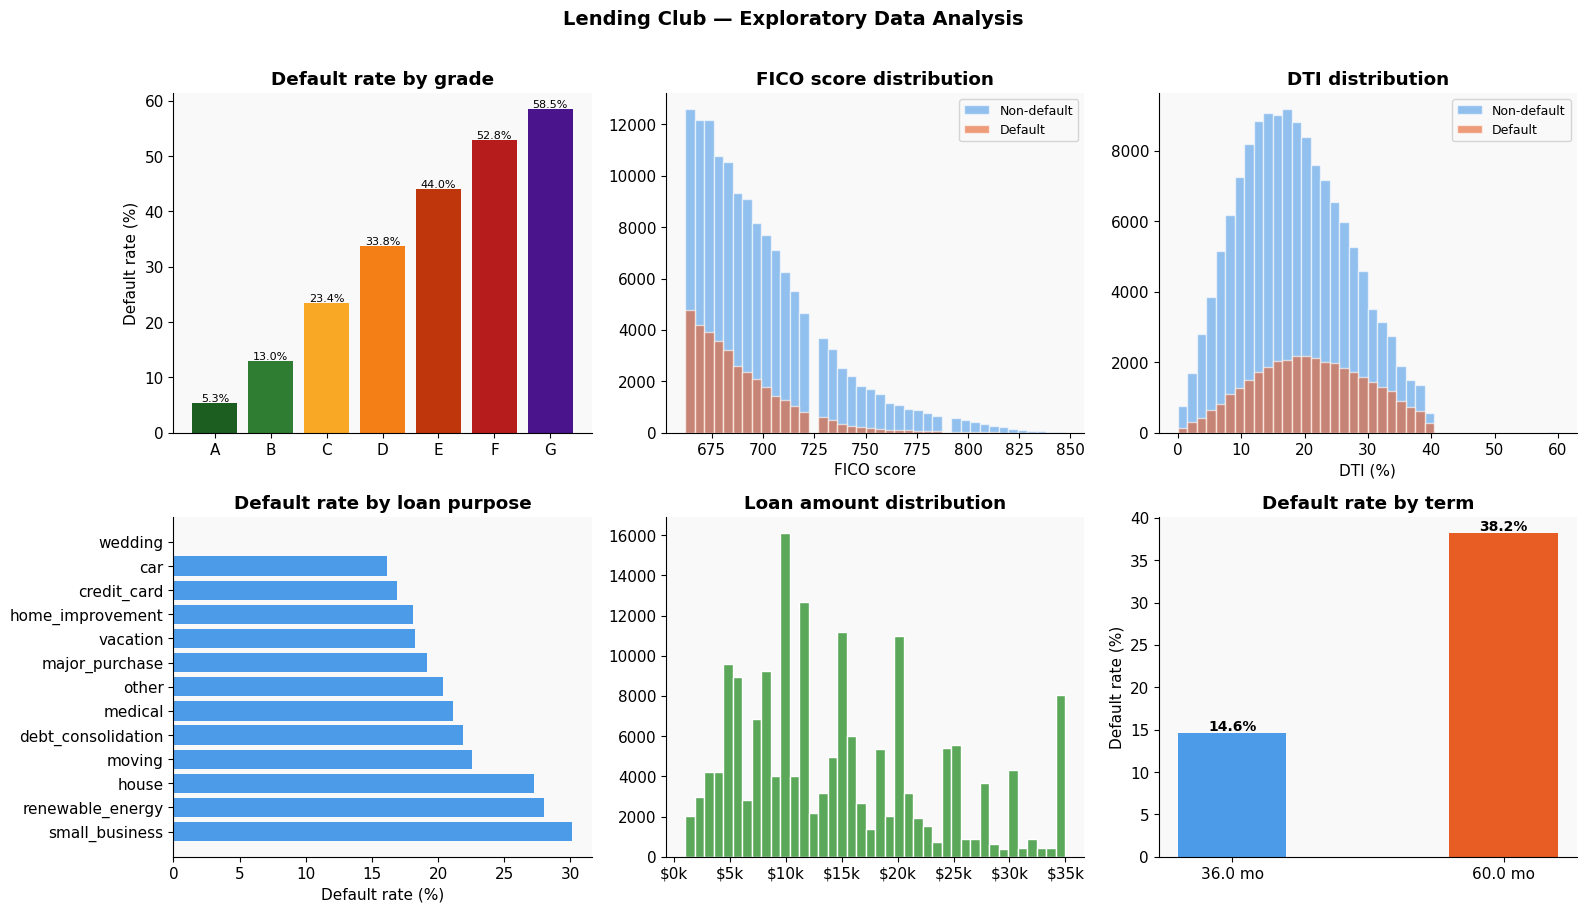

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Default rate by grade
grade_dr = df.groupby('grade')['default'].mean().sort_index() * 100
grade_colors = ['#1B5E20','#2E7D32','#F9A825','#F57F17','#BF360C','#B71C1C','#4A148C']
axes[0].bar(grade_dr.index, grade_dr.values, color=grade_colors)
for i, v in enumerate(grade_dr.values):
    axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)
axes[0].set_title('Default rate by grade', fontweight='bold')
axes[0].set_ylabel('Default rate (%)')

# FICO distribution
axes[1].hist(df[df['default']==0]['fico_score'], bins=40,
             color='#4C9BE8', alpha=0.6, label='Non-default', edgecolor='white')
axes[1].hist(df[df['default']==1]['fico_score'], bins=40,
             color='#E85D24', alpha=0.6, label='Default', edgecolor='white')
axes[1].set_title('FICO score distribution', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('FICO score')

# DTI distribution
axes[2].hist(df[df['default']==0]['dti'].clip(0,60), bins=40,
             color='#4C9BE8', alpha=0.6, label='Non-default', edgecolor='white')
axes[2].hist(df[df['default']==1]['dti'].clip(0,60), bins=40,
             color='#E85D24', alpha=0.6, label='Default', edgecolor='white')
axes[2].set_title('DTI distribution', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].set_xlabel('DTI (%)')

# Default rate by purpose
pur_dr = (df.groupby('purpose')['default'].mean() * 100).sort_values(ascending=False)
axes[3].barh(pur_dr.index, pur_dr.values, color='#4C9BE8')
axes[3].set_title('Default rate by loan purpose', fontweight='bold')
axes[3].set_xlabel('Default rate (%)')

# Loan amount distribution
axes[4].hist(df['loan_amnt'], bins=40, color='#5BA85A', edgecolor='white')
axes[4].set_title('Loan amount distribution', fontweight='bold')
axes[4].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Default rate by term
term_dr = df.groupby('term_months')['default'].mean() * 100
axes[5].bar(term_dr.index.astype(str).str.cat([' mo']*len(term_dr)),
            term_dr.values, color=['#4C9BE8','#E85D24'], width=0.4)
for i, v in enumerate(term_dr.values):
    axes[5].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[5].set_title('Default rate by term', fontweight='bold')
axes[5].set_ylabel('Default rate (%)')

plt.suptitle('Lending Club — Exploratory Data Analysis', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


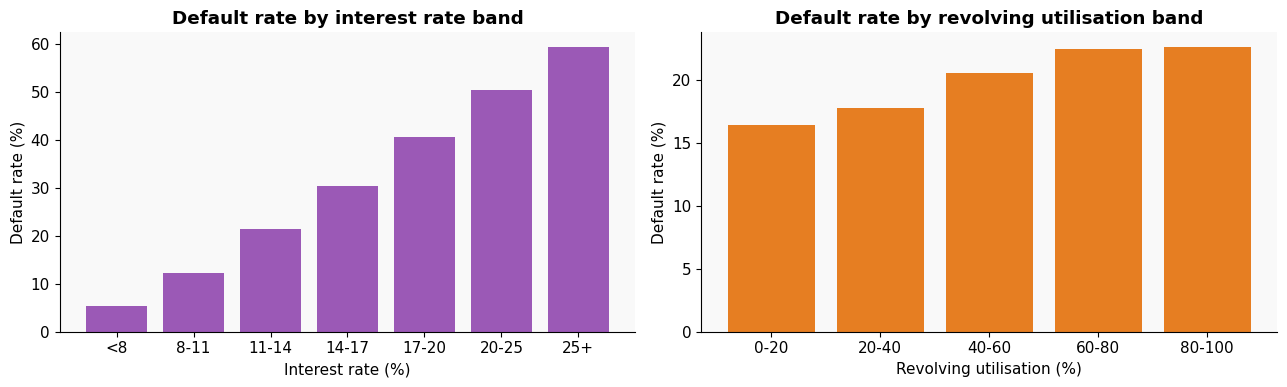

In [7]:
# Interest rate vs default — strong signal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

int_bins   = [0,8,11,14,17,20,25,31]
int_labels = ['<8','8-11','11-14','14-17','17-20','20-25','25+']
df['int_band'] = pd.cut(df['int_rate'], bins=int_bins, labels=int_labels)
int_dr = df.groupby('int_band', observed=True)['default'].mean() * 100
axes[0].bar(int_dr.index.astype(str), int_dr.values, color='#9B59B6')
axes[0].set_title('Default rate by interest rate band', fontweight='bold')
axes[0].set_ylabel('Default rate (%)')
axes[0].set_xlabel('Interest rate (%)')

# Revol utilisation vs default
rev_bins   = [0,20,40,60,80,100]
rev_labels = ['0-20','20-40','40-60','60-80','80-100']
df['rev_band'] = pd.cut(df['revol_util'].clip(0,100), bins=rev_bins, labels=rev_labels)
rev_dr = df.groupby('rev_band', observed=True)['default'].mean() * 100
axes[1].bar(rev_dr.index.astype(str), rev_dr.values, color='#E67E22')
axes[1].set_title('Default rate by revolving utilisation band', fontweight='bold')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Revolving utilisation (%)')

plt.tight_layout()
plt.show()


## 5. Feature Engineering

In [8]:
def engineer_features(df):
    df = df.copy()

    # Log-transform skewed features
    df['log_annual_inc'] = np.log1p(df['annual_inc'])
    df['log_loan_amnt']  = np.log1p(df['loan_amnt'])
    df['log_revol_bal']  = np.log1p(df['revol_bal'])

    # Risk flag features (binary — business-interpretable)
    df['flag_high_dti']        = (df['dti'] >= 35).astype(int)
    df['flag_low_fico']        = (df['fico_score'] < 620).astype(int)
    df['flag_high_revol']      = (df['revol_util'] >= 80).astype(int)
    df['flag_high_pti']        = (df['payment_to_income'] >= 0.20).astype(int)
    df['flag_delinq']          = df['delinq_flag']
    df['flag_pub_rec']         = (df['pub_rec'].fillna(0) > 0).astype(int)
    df['flag_bankruptcy']      = (df['pub_rec_bankruptcies'].fillna(0) > 0).astype(int)
    df['flag_60mo_term']       = (df['term_months'] == 60).astype(int)
    df['flag_high_int']        = (df['int_rate'] >= 20).astype(int)

    # Home ownership dummies
    home_dummies = pd.get_dummies(df['home_ownership'], prefix='home', drop_first=True)
    df = pd.concat([df, home_dummies], axis=1)

    # Purpose dummies
    purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True)
    df = pd.concat([df, purpose_dummies], axis=1)

    # Verification status dummy
    df['is_verified'] = (df['verification_status'] != 'Not Verified').astype(int)

    return df

df = engineer_features(df)
print(f"Engineered dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")


Engineered dataset: 176,868 rows × 62 columns


## 6. Model Training

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Define Feature Lists
base_features = [
    'fico_score', 'dti', 'int_rate', 'log_annual_inc', 'log_loan_amnt',
    'revol_util', 'open_acc', 'pub_rec', 'delinq_2yrs',
    'payment_to_income', 'loan_to_income', 'emp_years',
    'term_months', 'grade_n', 'mort_acc', 'total_acc',
    'is_verified', 'log_revol_bal',
    'flag_high_dti', 'flag_low_fico', 'flag_high_revol',
    'flag_high_pti', 'flag_delinq', 'flag_pub_rec',
    'flag_bankruptcy', 'flag_60mo_term', 'flag_high_int',
]

# Dynamically grab dummy columns if they exist, or the original categorical columns
home_cols    = [c for c in df.columns if c.startswith('home_')]
purpose_cols = [c for c in df.columns if c.startswith('purpose_')]
MODEL_FEATURES = base_features + home_cols + purpose_cols

# 2. Data Cleaning & Splitting
df_model = df[MODEL_FEATURES + ['default']].dropna()

X = df_model[MODEL_FEATURES]
y = df_model['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. CRITICAL: Identify Column Types
# This tells the transformer exactly which columns contain strings like 'MORTGAGE'
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 4. Build the Pipeline with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000, C=0.5,
        class_weight='balanced',
        solver='lbfgs', random_state=42
    ))
])

# 5. Fit and Predict
pipe.fit(X_train, y_train)

y_prob_train = pipe.predict_proba(X_train)[:, 1]
y_prob_test  = pipe.predict_proba(X_test)[:, 1]

# 6. Evaluation Metrics
auc  = roc_auc_score(y_test, y_prob_test)
gini = 2 * auc - 1

def ks_stat(y_true, y_score):
    df_ks = pd.DataFrame({'s': y_score, 't': y_true}).sort_values('s')
    n_p, n_n = y_true.sum(), (y_true==0).sum()
    return ((df_ks['t']==1).cumsum()/n_p - (df_ks['t']==0).cumsum()/n_n).abs().max()

ks = ks_stat(y_test, y_prob_test)

# 7. Cross-Validation
cv_scores = cross_val_score(
    pipe, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

# 8. Final Output
print(f"Modelling rows  : {len(df_model):,}  ({len(df_model)/len(df)*100:.1f}% retained)")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

print(f"\n{'─'*42}")
print(f"   PD Model Performance")
print(f"{'─'*42}")
print(f"   AUC (test)       : {auc:.4f}")
print(f"   Gini             : {gini:.4f}")
print(f"   KS               : {ks:.4f}")
print(f"   CV AUC (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"{'─'*42}")


Modelling rows  : 176,868  (100.0% retained)
Train: 141,494  |  Test: 35,374
Train default rate: 20.28%  |  Test: 20.28%

──────────────────────────────────────────
   PD Model Performance
──────────────────────────────────────────
   AUC (test)       : 0.7412
   Gini             : 0.4823
   KS               : 0.3533
   CV AUC (5-fold)  : 0.7405 ± 0.0012
──────────────────────────────────────────


## 7. Model Evaluation Plots

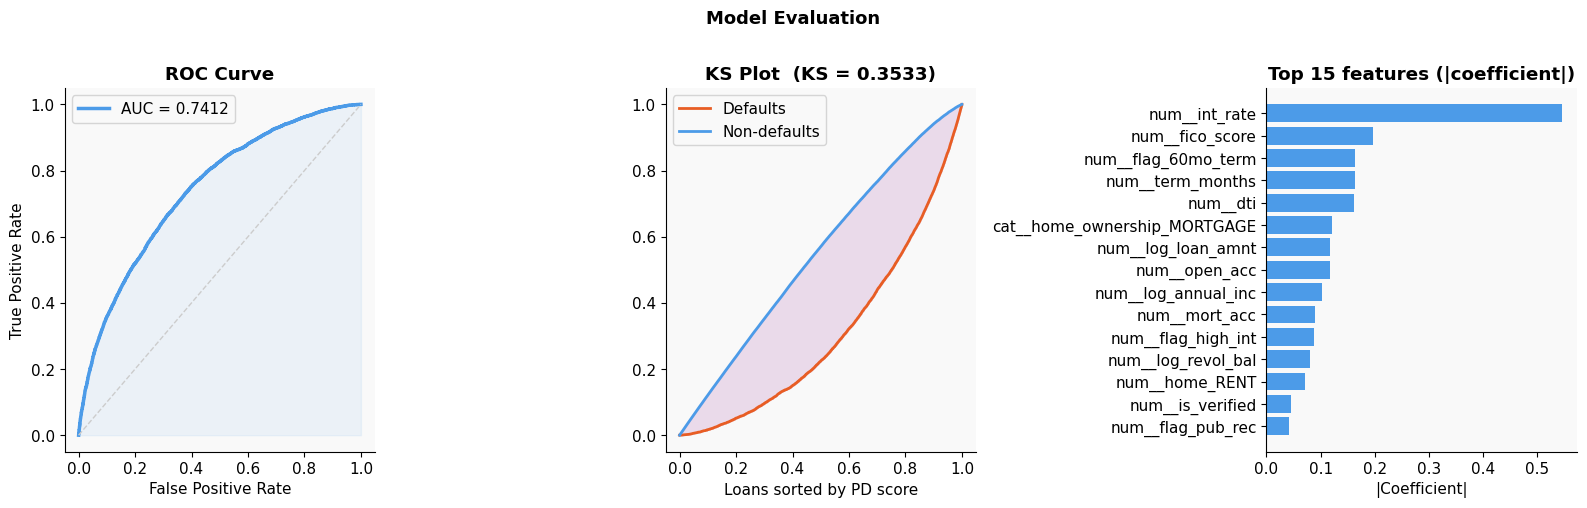

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0].plot(fpr, tpr, color='#4C9BE8', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#4C9BE8')
axes[0].plot([0,1],[0,1],'--', color='#cccccc', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# KS plot
df_ks = pd.DataFrame({
    's': y_prob_test, 
    't': y_test.values  # .values ensures we don't have index mismatches
}).sort_values('s')
n_p, n_n = y_test.sum(), (y_test==0).sum()
cum_p = (df_ks['t']==1).cumsum() / n_p
cum_n = (df_ks['t']==0).cumsum() / n_n
x_ax  = np.linspace(0, 1, len(df_ks))
axes[1].plot(x_ax, cum_p.values, label='Defaults',     color='#E85D24', lw=2)
axes[1].plot(x_ax, cum_n.values, label='Non-defaults', color='#4C9BE8', lw=2)
axes[1].fill_between(x_ax, cum_p.values, cum_n.values, alpha=0.12, color='purple')
axes[1].set_title(f'KS Plot  (KS = {ks:.4f})', fontweight='bold')
axes[1].set_xlabel('Loans sorted by PD score')
axes[1].legend()

# Feature importance (coefficients)
# 1. Get the feature names from the preprocessor
# This maps the coefficients to the correct expanded column names
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

# 2. Create the series using the NEW feature names
coef_series = pd.Series(
    pipe.named_steps['model'].coef_[0], 
    index=feature_names  # Use the dynamic names here!
).abs().sort_values(ascending=False).head(15)

# 3. Plotting (same as before)
axes[2].barh(coef_series.index[::-1], coef_series.values[::-1], color='#4C9BE8')
axes[2].set_title('Top 15 features (|coefficient|)', fontweight='bold')
axes[2].set_xlabel('|Coefficient|')

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 8. Threshold Tuning

Threshold selected (bad rate cap ≤15%): 0.635


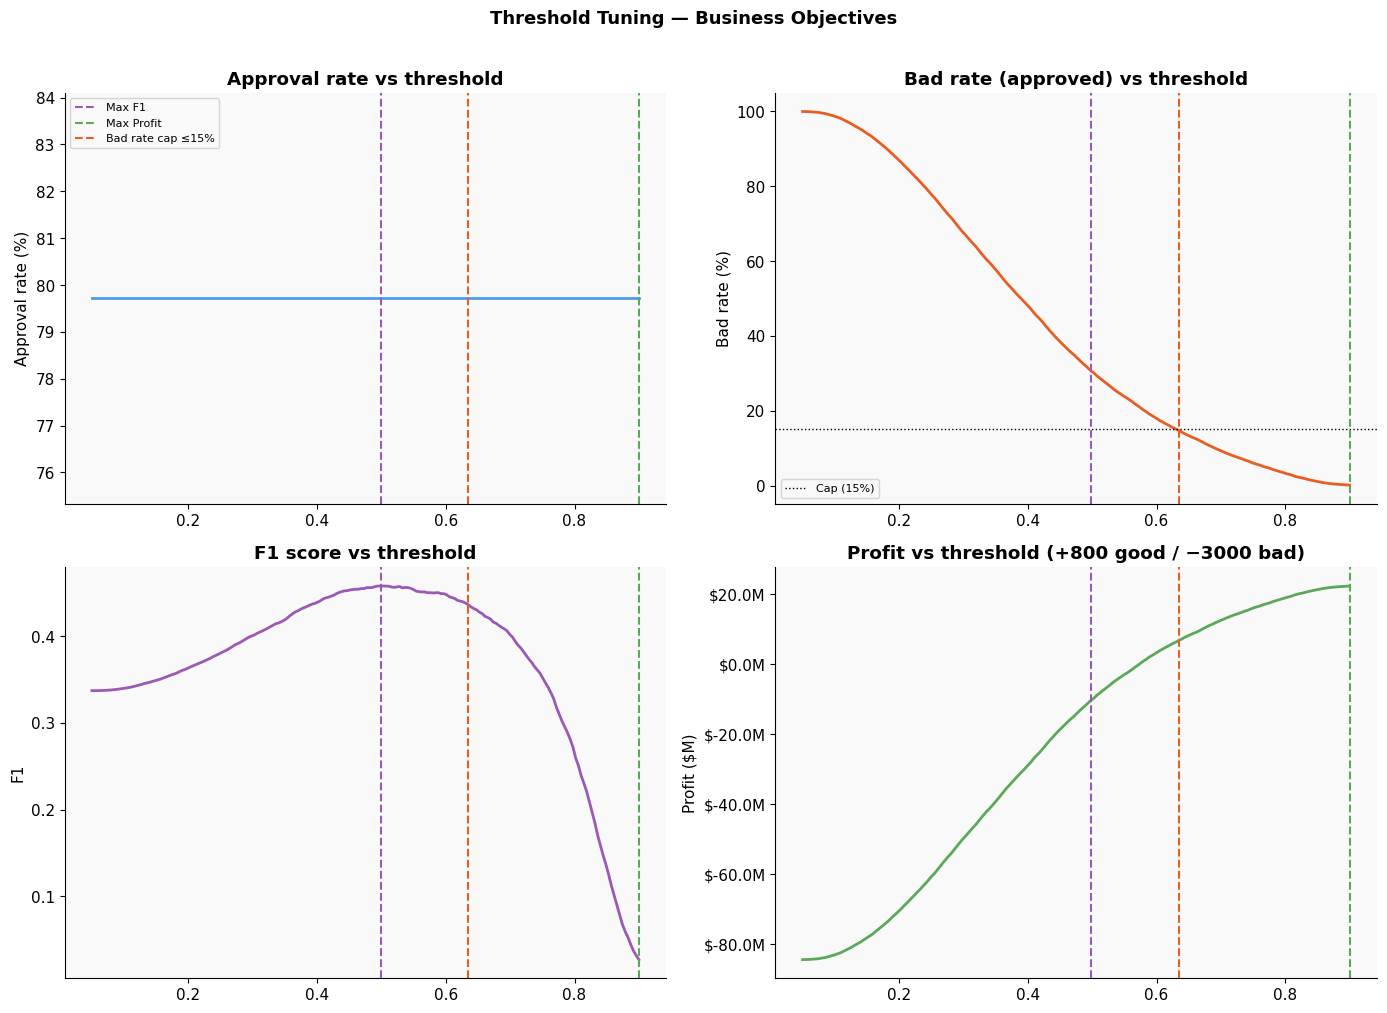

In [15]:
thresholds = np.linspace(0.05, 0.90, 200)
BAD_RATE_CAP = 0.15   # Lending Club real default rate is higher — cap set at 15%

records = []
for t in thresholds:
    y_pred = (y_prob_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    approved      = tn + fp
    approval_rate = approved / len(y_test)
    bad_rate      = fp / approved if approved > 0 else 0
    profit        = (tn * 800) - (fp * 3000)   # revenue per good, loss per bad
    f1            = f1_score(y_test, y_pred, zero_division=0)

    records.append({
        'threshold': t, 'approval_rate': approval_rate,
        'bad_rate': bad_rate, 'profit': profit, 'f1': f1,
    })

results_df = pd.DataFrame(records)

t_f1     = results_df.loc[results_df['f1'].idxmax(),     'threshold']
t_profit = results_df.loc[results_df['profit'].idxmax(), 'threshold']
eligible = results_df[results_df['bad_rate'] <= BAD_RATE_CAP]
t_badcap = (eligible.loc[eligible['approval_rate'].idxmax(), 'threshold']
            if len(eligible) > 0 else 0.5)

THRESHOLD = t_badcap
print(f"Threshold selected (bad rate cap ≤{BAD_RATE_CAP:.0%}): {THRESHOLD:.3f}")

vline_specs = [
    (t_f1,     '#9B59B6', 'Max F1'),
    (t_profit, '#5BA85A', 'Max Profit'),
    (t_badcap, '#E85D24', f'Bad rate cap ≤{BAD_RATE_CAP:.0%}'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(results_df['threshold'], results_df['approval_rate']*100,
               color='#4C9BE8', lw=2)
axes[0,0].set_title('Approval rate vs threshold', fontweight='bold')
axes[0,0].set_ylabel('Approval rate (%)')
for t,c,l in vline_specs: axes[0,0].axvline(t, color=c, linestyle='--', lw=1.5, label=l)
axes[0,0].legend(fontsize=8)

axes[0,1].plot(results_df['threshold'], results_df['bad_rate']*100,
               color='#E85D24', lw=2)
axes[0,1].axhline(BAD_RATE_CAP*100, color='black', linestyle=':', lw=1,
                  label=f'Cap ({BAD_RATE_CAP:.0%})')
axes[0,1].set_title('Bad rate (approved) vs threshold', fontweight='bold')
axes[0,1].set_ylabel('Bad rate (%)')
for t,c,l in vline_specs: axes[0,1].axvline(t, color=c, linestyle='--', lw=1.5)
axes[0,1].legend(fontsize=8)

axes[1,0].plot(results_df['threshold'], results_df['f1'],
               color='#9B59B6', lw=2)
axes[1,0].set_title('F1 score vs threshold', fontweight='bold')
axes[1,0].set_ylabel('F1')
for t,c,l in vline_specs: axes[1,0].axvline(t, color=c, linestyle='--', lw=1.5)

axes[1,1].plot(results_df['threshold'], results_df['profit']/1e6,
               color='#5BA85A', lw=2)
axes[1,1].set_title('Profit vs threshold (+800 good / −3000 bad)', fontweight='bold')
axes[1,1].set_ylabel('Profit ($M)')
axes[1,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:.1f}M'))
for t,c,l in vline_specs: axes[1,1].axvline(t, color=c, linestyle='--', lw=1.5)

plt.suptitle('Threshold Tuning — Business Objectives', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [16]:
# Attach PD to model dataset
df_model = df_model.copy()
df_model['PD']             = pipe.predict_proba(X)[:, 1]
df_model['model_decision'] = (df_model['PD'] < THRESHOLD).map(
    {True: 'APPROVE', False: 'DECLINE'})

# Merge back key columns for rules layer
rule_cols = ['grade','dti','fico_score','int_rate','delinq_2yrs','pub_rec',
             'pub_rec_bankruptcies','revol_util','payment_to_income',
             'annual_inc','loan_amnt','term_months','emp_years','loan_purpose',
             'flag_bankruptcy','flag_delinq']

for col in rule_cols:
    if col in df.columns:
        df_model[col] = df.loc[df_model.index, col].values

print(f"Model applied  : {len(df_model):,} loans")
print(f"Model approval : {(df_model['model_decision']=='APPROVE').mean():.1%}")


Model applied  : 176,868 loans
Model approval : 79.5%


## 9. Rule-Based Override Layer
Policy rules that mirror how Indian NBFCs and banks layer credit policy on top of scorecards. Hard declines are based on RBI prudential norms; auto-approvals mirror prime-segment fast-track policies.

In [17]:
HARD_DECLINE_RULES = [
    (
        lambda r: r.get('dti', 0) > 50,
        'HARD_DECLINE', 'HD001',
        'DTI > 50% — exceeds RBI-aligned maximum policy limit'
    ),
    (
        lambda r: r.get('fico_score', 999) < 580,
        'HARD_DECLINE', 'HD002',
        'FICO below 580 — subprime threshold'
    ),
    (
        lambda r: r.get('pub_rec_bankruptcies', 0) > 0,
        'HARD_DECLINE', 'HD003',
        'Bankruptcy on record — automatic decline'
    ),
    (
        lambda r: r.get('delinq_2yrs', 0) >= 3,
        'HARD_DECLINE', 'HD004',
        'Three or more delinquencies in past 24 months'
    ),
    (
        lambda r: r.get('int_rate', 0) >= 28,
        'HARD_DECLINE', 'HD005',
        'Interest rate ≥28% — indicative of extreme risk tier'
    ),
    (
        lambda r: r.get('payment_to_income', 0) > 0.30,
        'HARD_DECLINE', 'HD006',
        'Annual payments exceed 30% of gross income (PTI breach)'
    ),
    (
        lambda r: r.get('pub_rec', 0) >= 3,
        'HARD_DECLINE', 'HD007',
        'Three or more adverse public records'
    ),
]

AUTO_APPROVE_RULES = [
    (
        lambda r: (r.get('fico_score', 0) >= 750 and
                   r.get('dti', 999) < 20 and
                   r.get('delinq_2yrs', 999) == 0 and
                   r.get('pub_rec_bankruptcies', 1) == 0 and
                   r.get('grade', 'G') in ['A', 'B']),
        'AUTO_APPROVE', 'AA001',
        'Prime applicant — FICO≥750, DTI<20%, Grade A/B, clean record'
    ),
    (
        lambda r: (r.get('fico_score', 0) >= 720 and
                   r.get('dti', 999) < 15 and
                   r.get('emp_years', 0) >= 7 and
                   r.get('revol_util', 999) < 30 and
                   r.get('pub_rec_bankruptcies', 1) == 0),
        'AUTO_APPROVE', 'AA002',
        'Stable prime — FICO≥720, DTI<15%, 7+ years employment, low utilisation'
    ),
]

def apply_rules(row):
    row_dict = row.to_dict()
    for cond, decision, code, desc in HARD_DECLINE_RULES:
        try:
            if cond(row_dict):
                return decision, code, desc, True
        except Exception:
            pass
    for cond, decision, code, desc in AUTO_APPROVE_RULES:
        try:
            if cond(row_dict):
                return decision, code, desc, True
        except Exception:
            pass
    return row_dict.get('model_decision', 'DECLINE'), 'MODEL', 'Model-based decision', False

print("Applying rule layer (this may take ~30s on 200k rows)...")
rule_results = df_model.apply(apply_rules, axis=1, result_type='expand')
rule_results.columns = ['final_decision','reason_code','reason_desc','override_flag']
df_model = pd.concat([df_model, rule_results], axis=1)

total     = len(df_model)
approved  = df_model['final_decision'].isin(['APPROVE','AUTO_APPROVE']).sum()
declined  = df_model['final_decision'].isin(['DECLINE','HARD_DECLINE']).sum()
overrides = df_model['override_flag'].sum()

print(f"\n{'─'*50}")
print(f"  Decision Engine  ({total:,} loans)")
print(f"{'─'*50}")
print(f"  Approved          : {approved:>7,}  ({approved/total:.1%})")
print(f"  Declined          : {declined:>7,}  ({declined/total:.1%})")
print(f"  Rule overrides    : {overrides:>7,}  ({overrides/total:.1%})")
print(f"{'─'*50}")
print("\nFull decision breakdown:")
print(df_model['final_decision'].value_counts().to_string())


Applying rule layer (this may take ~30s on 200k rows)...

──────────────────────────────────────────────────
  Decision Engine  (176,868 loans)
──────────────────────────────────────────────────
  Approved          : 119,784  (67.7%)
  Declined          :  57,084  (32.3%)
  Rule overrides    :  37,024  (20.9%)
──────────────────────────────────────────────────

Full decision breakdown:
final_decision
APPROVE         111109
DECLINE          28735
HARD_DECLINE     28349
AUTO_APPROVE      8675


## 10. Override Analysis

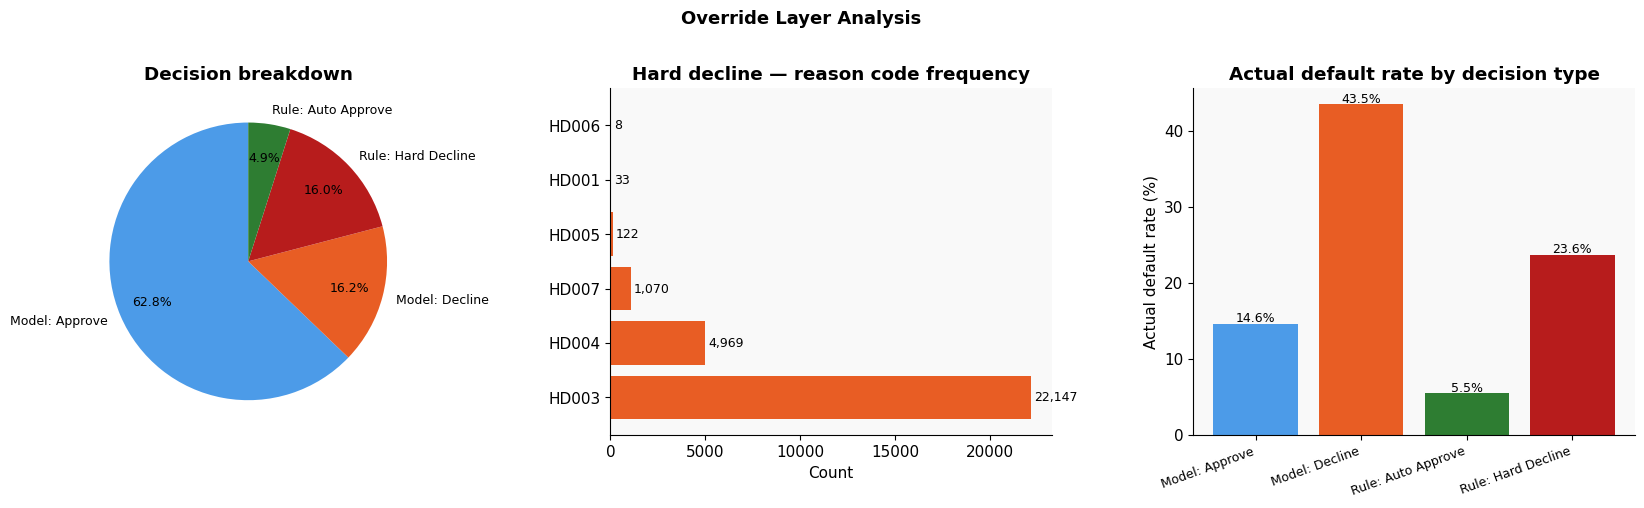

In [18]:
def override_category(row):
    if row['override_flag']:
        if 'HARD_DECLINE' in row['final_decision']:
            return 'Rule: Hard Decline'
        return 'Rule: Auto Approve'
    return 'Model: Approve' if row['final_decision'] == 'APPROVE' else 'Model: Decline'

df_model['override_category'] = df_model.apply(override_category, axis=1)

cat_counts = df_model['override_category'].value_counts()
cat_colors = {
    'Rule: Hard Decline' : '#B71C1C',
    'Model: Decline'     : '#E85D24',
    'Model: Approve'     : '#4C9BE8',
    'Rule: Auto Approve' : '#2E7D32',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Pie
colors_pie = [cat_colors.get(c,'#999') for c in cat_counts.index]
axes[0].pie(cat_counts.values, labels=cat_counts.index,
            colors=colors_pie, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75, textprops={'fontsize':9})
axes[0].set_title('Decision breakdown', fontweight='bold')

# Hard decline reason codes
hd = df_model[df_model['final_decision']=='HARD_DECLINE']['reason_code'].value_counts()
axes[1].barh(hd.index, hd.values, color='#E85D24')
axes[1].set_title('Hard decline — reason code frequency', fontweight='bold')
axes[1].set_xlabel('Count')
for i, (code, cnt) in enumerate(hd.items()):
    axes[1].text(cnt + len(df_model)*0.001, i, f'{cnt:,}', va='center', fontsize=9)

# Default rate by decision category
dr_cat = df_model.groupby('override_category')['default'].mean() * 100
bar_colors = [cat_colors.get(c,'#999') for c in dr_cat.index]
axes[2].bar(range(len(dr_cat)), dr_cat.values, color=bar_colors)
axes[2].set_xticks(range(len(dr_cat)))
axes[2].set_xticklabels(dr_cat.index, rotation=20, ha='right', fontsize=9)
axes[2].set_ylabel('Actual default rate (%)')
axes[2].set_title('Actual default rate by decision type', fontweight='bold')
for i, v in enumerate(dr_cat.values):
    axes[2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Override Layer Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 11. Grade-Level Decision Heatmap

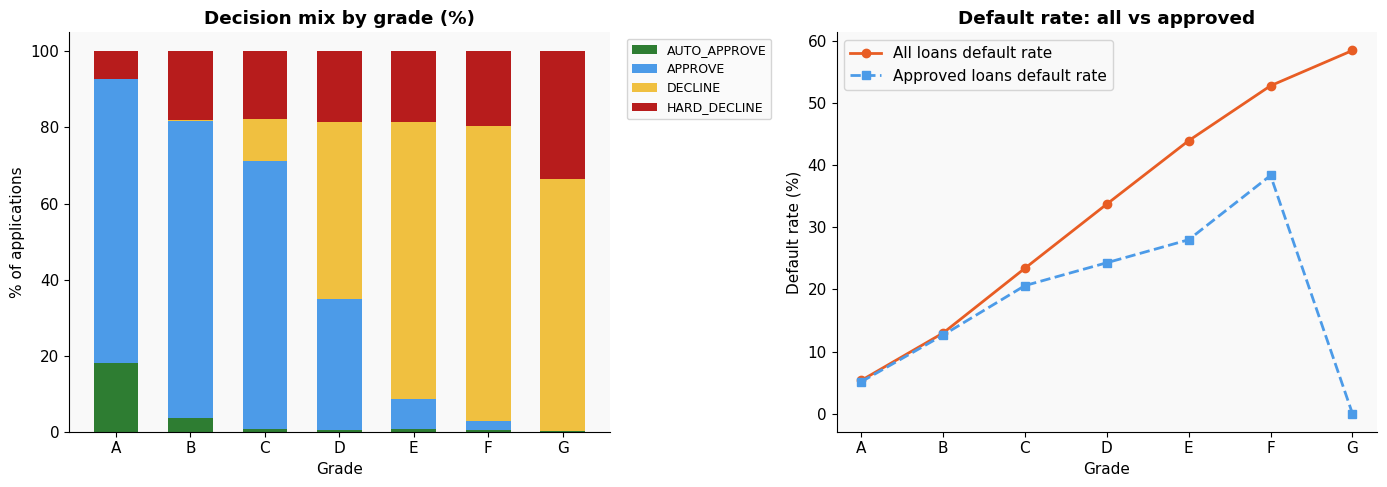

In [19]:
# Decision outcome breakdown by Lending Club grade — key portfolio view
grade_decision = (df_model.groupby(['grade','final_decision'])
                  .size()
                  .unstack(fill_value=0))

# Normalise to row %
grade_decision_pct = grade_decision.div(grade_decision.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
bottom = np.zeros(len(grade_decision_pct))
decision_colors = {
    'AUTO_APPROVE' : '#2E7D32',
    'APPROVE'      : '#4C9BE8',
    'DECLINE'      : '#F0C040',
    'HARD_DECLINE' : '#B71C1C',
}
for dec in ['AUTO_APPROVE','APPROVE','DECLINE','HARD_DECLINE']:
    if dec in grade_decision_pct.columns:
        vals = grade_decision_pct[dec].values
        axes[0].bar(grade_decision_pct.index, vals,
                    bottom=bottom, label=dec,
                    color=decision_colors.get(dec,'#999'), width=0.6)
        bottom += vals

axes[0].set_title('Decision mix by grade (%)', fontweight='bold')
axes[0].set_ylabel('% of applications')
axes[0].legend(fontsize=9, bbox_to_anchor=(1.02,1))
axes[0].set_xlabel('Grade')

# Default rate by grade × actual outcomes
grade_dr = df_model.groupby('grade')['default'].mean() * 100
approved_dr = (df_model[df_model['final_decision'].isin(['APPROVE','AUTO_APPROVE'])]
               .groupby('grade')['default'].mean() * 100)
axes[1].plot(grade_dr.index, grade_dr.values, 'o-',
             color='#E85D24', lw=2, label='All loans default rate')
if len(approved_dr) > 0:
    axes[1].plot(approved_dr.index, approved_dr.values, 's--',
                 color='#4C9BE8', lw=2, label='Approved loans default rate')
axes[1].set_title('Default rate: all vs approved', fontweight='bold')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Grade')
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Audit Trail

In [20]:
audit_cols = [
    'loan_amnt', 'int_rate', 'grade', 'fico_score', 'dti',
    'annual_inc', 'emp_years', 'delinq_2yrs', 'pub_rec',
    'payment_to_income', 'term_months', 'loan_purpose',
    'PD', 'model_decision', 'final_decision',
    'reason_code', 'reason_desc', 'override_flag', 'default',
]

audit_df = df_model[[c for c in audit_cols if c in df_model.columns]].copy()
audit_df['PD_pct']      = (audit_df['PD'] * 100).round(2)
audit_df['risk_tier']   = pd.cut(
    audit_df['PD'],
    bins=[0, 0.05, 0.12, 0.22, 0.35, 1.0],
    labels=['Very Low','Low','Medium','High','Very High']
)
audit_df['decision_date'] = pd.Timestamp.now().strftime('%Y-%m-%d')

print("Sample audit records (5 random):")
pd.set_option('display.max_colwidth', 50)
sample = audit_df.sample(5, random_state=7)[[
    'grade','fico_score','dti','PD_pct',
    'model_decision','final_decision','reason_code','override_flag'
]]
print(sample.to_string(index=False))


Sample audit records (5 random):
grade  fico_score   dti  PD_pct model_decision final_decision reason_code  override_flag
    C       662.0 24.35   56.16        APPROVE        APPROVE       MODEL          False
    G       667.0  6.18   85.56        DECLINE        DECLINE       MODEL          False
    C       662.0 14.86   48.78        APPROVE        APPROVE       MODEL          False
    B       702.0 17.44   26.68        APPROVE        APPROVE       MODEL          False
    C       712.0 38.09   51.51        APPROVE        APPROVE       MODEL          False


## 13. Portfolio Simulation — What-If Analysis

Policy simulation:
Bad rate cap  PD threshold  Approval rate  Actual bad rate  Exp. loss ($M)  N approved
          8%         0.144          0.041            0.020          12.153        7211
         10%         0.180          0.079            0.030          29.052       14030
         12%         0.216          0.126            0.039          53.177       22272
         15%         0.270          0.204            0.052         101.515       36158
         18%         0.324          0.287            0.065         160.635       50685
         20%         0.360          0.341            0.074         204.375       60274
         25%         0.450          0.475            0.097         333.290       84032


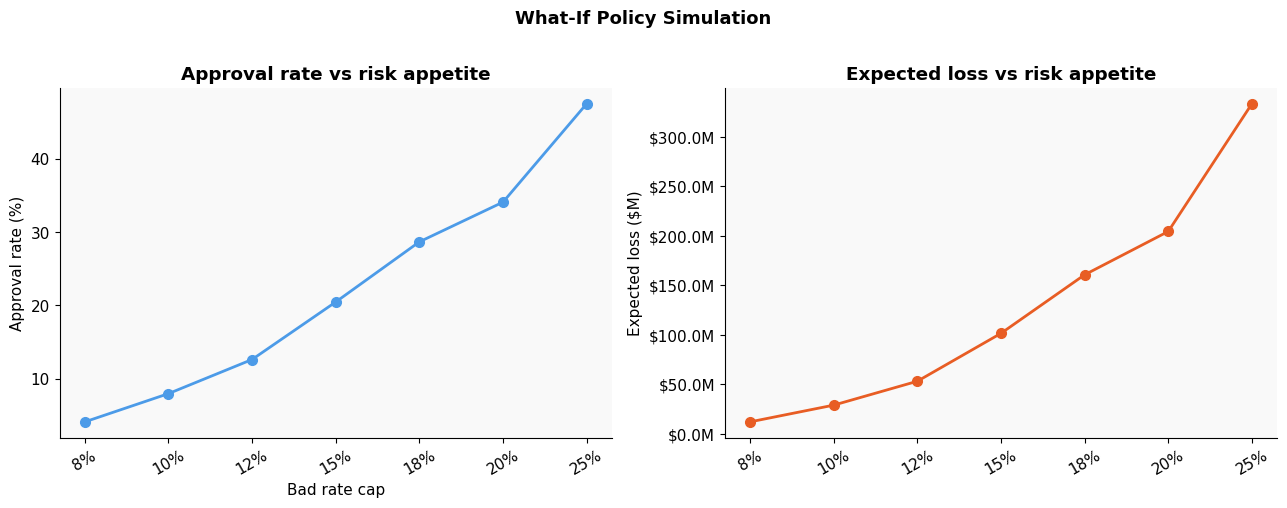

In [21]:
def simulate_policy(df, pd_threshold, dti_limit=50, min_fico=580):
    """Re-run decision engine with different threshold and policy parameters."""
    mask_hd = (
        (df['dti'] > dti_limit) |
        (df['fico_score'] < min_fico) |
        (df.get('pub_rec_bankruptcies', pd.Series(0, index=df.index)).fillna(0) > 0) |
        (df.get('delinq_2yrs', pd.Series(0, index=df.index)).fillna(0) >= 3)
    )
    mask_model_approve = (~mask_hd) & (df['PD'] < pd_threshold)
    approved = df[mask_model_approve]

    return {
        'approval_rate' : mask_model_approve.mean(),
        'bad_rate'      : approved['default'].mean() if len(approved) > 0 else 0,
        'exp_loss'      : (approved['PD'] * approved['loan_amnt']).sum(),
        'n_approved'    : mask_model_approve.sum(),
    }

scenarios = []
for br_cap in [0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]:
    pd_thresh = br_cap * 1.8  # approximate PD threshold to hit the bad rate cap
    res = simulate_policy(df_model, pd_threshold=pd_thresh)
    scenarios.append({
        'Bad rate cap'   : f'{br_cap:.0%}',
        'PD threshold'   : round(pd_thresh, 3),
        'Approval rate'  : res['approval_rate'],
        'Actual bad rate': res['bad_rate'],
        'Exp. loss ($M)' : res['exp_loss'] / 1e6,
        'N approved'     : res['n_approved'],
    })

sim_df = pd.DataFrame(scenarios)
print("Policy simulation:")
print(sim_df.to_string(index=False, float_format='{:.3f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sim_df['Bad rate cap'], sim_df['Approval rate']*100,
             'o-', color='#4C9BE8', lw=2, markersize=7)
axes[0].set_title('Approval rate vs risk appetite', fontweight='bold')
axes[0].set_ylabel('Approval rate (%)')
axes[0].set_xlabel('Bad rate cap')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(sim_df['Bad rate cap'], sim_df['Exp. loss ($M)'],
             'o-', color='#E85D24', lw=2, markersize=7)
axes[1].set_title('Expected loss vs risk appetite', fontweight='bold')
axes[1].set_ylabel('Expected loss ($M)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:.1f}M'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('What-If Policy Simulation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 14. Export

In [22]:
os.makedirs('outputs', exist_ok=True)

audit_df.to_csv('outputs/lc_loan_decisions_audit.csv', index=False)

band_summary = (df_model.groupby('override_category', observed=True)
                .agg(
                    count          = ('PD', 'count'),
                    avg_pd         = ('PD', 'mean'),
                    actual_dr      = ('default', 'mean'),
                    avg_loan       = ('loan_amnt', 'mean'),
                    total_exposure = ('loan_amnt', 'sum'),
                )
                .reset_index())
band_summary.to_csv('outputs/lc_decision_band_summary.csv', index=False)

rule_freq = (df_model.groupby('reason_code')
             .agg(count=('reason_code','count'),
                  default_rate=('default','mean'))
             .reset_index()
             .sort_values('count', ascending=False))
rule_freq.to_csv('outputs/lc_rule_trigger_frequency.csv', index=False)

sim_df.to_csv('outputs/lc_policy_simulation.csv', index=False)

print("Exports:")
print("  outputs/lc_loan_decisions_audit.csv      ← full audit trail")
print("  outputs/lc_decision_band_summary.csv     ← Tableau summary")
print("  outputs/lc_rule_trigger_frequency.csv    ← rule fire frequency")
print("  outputs/lc_policy_simulation.csv         ← what-if scenarios")


Exports:
  outputs/lc_loan_decisions_audit.csv      ← full audit trail
  outputs/lc_decision_band_summary.csv     ← Tableau summary
  outputs/lc_rule_trigger_frequency.csv    ← rule fire frequency
  outputs/lc_policy_simulation.csv         ← what-if scenarios


## 15. Final Summary

In [23]:
bad_approved = df_model[
    df_model['final_decision'].isin(['APPROVE','AUTO_APPROVE'])
]['default'].mean()
n_auto_app  = (df_model['final_decision'] == 'AUTO_APPROVE').sum()
n_hd        = (df_model['final_decision'] == 'HARD_DECLINE').sum()

print("=" * 58)
print("  LENDING CLUB — LOAN APPROVAL ENGINE SUMMARY")
print("=" * 58)
print(f"  Loans processed        : {total:>9,}")
print()
print(f"  PD Model:")
print(f"    AUC                  : {auc:.4f}")
print(f"    Gini                 : {gini:.4f}")
print(f"    KS statistic         : {ks:.4f}")
print(f"    CV AUC (5-fold)      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"    Working threshold    : {THRESHOLD:.3f}")
print()
print(f"  Decisions:")
print(f"    Auto-approvals       : {n_auto_app:>9,}  ({n_auto_app/total:.1%})")
print(f"    Model approvals      : {(df_model['final_decision']=='APPROVE').sum():>9,}  ({(df_model['final_decision']=='APPROVE').mean():.1%})")
print(f"    Model declines       : {(df_model['final_decision']=='DECLINE').sum():>9,}  ({(df_model['final_decision']=='DECLINE').mean():.1%})")
print(f"    Hard declines        : {n_hd:>9,}  ({n_hd/total:.1%})")
print(f"    Total approved       : {approved:>9,}  ({approved/total:.1%})")
print()
print(f"  Portfolio quality:")
print(f"    Bad rate (approved)  : {bad_approved:.2%}")
print(f"    Risk appetite cap    : {BAD_RATE_CAP:.2%}")
print(f"    Cap met?             : {'YES ✓' if bad_approved <= BAD_RATE_CAP else 'NO ⚠'}")
print(f"    Rule overrides       : {overrides:>9,}  ({overrides/total:.1%})")
print("=" * 58)


  LENDING CLUB — LOAN APPROVAL ENGINE SUMMARY
  Loans processed        :   176,868

  PD Model:
    AUC                  : 0.7412
    Gini                 : 0.4823
    KS statistic         : 0.3533
    CV AUC (5-fold)      : 0.7405 ± 0.0012
    Working threshold    : 0.635

  Decisions:
    Auto-approvals       :     8,675  (4.9%)
    Model approvals      :   111,109  (62.8%)
    Model declines       :    28,735  (16.2%)
    Hard declines        :    28,349  (16.0%)
    Total approved       :   119,784  (67.7%)

  Portfolio quality:
    Bad rate (approved)  : 13.92%
    Risk appetite cap    : 15.00%
    Cap met?             : YES ✓
    Rule overrides       :    37,024  (20.9%)
